# Supply Chain Optimization - Notebook 03: Summary

**Project:** Supply Chain Cost & Operational Efficiency Analysis  
**Dataset:** [Supply Chain DataSet](https://www.kaggle.com/datasets/amirmotefaker/supply-chain-dataset) - [Amir Motefaker](https://www.kaggle.com/amirmotefaker) (Kaggle)  
**Analyst:** *Jakub Siuda*  
**Date:** *28/03/2026*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 11,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
    'text.parse_math': False
})

COLORS = {
    'primary': '#2E4057',
    'secondary': '#048A81',
    'accent': '#E76F51',
    'neutral': '#8D99AE',
    'light': '#EDF2F4',
    'highlight': '#F4A261'
}

CARRIER_COLORS  = {'Carrier A': '#2E4057', 'Carrier B': '#E76F51', 'Carrier C': '#048A81'}
PRODUCT_COLORS  = {'haircare': '#2E4057',  'skincare': '#048A81',  'cosmetics': '#F4A261'}
SUPPLIER_COLORS = {
    'Supplier 1': '#2E4057', 'Supplier 2': '#048A81',
    'Supplier 3': '#F4A261', 'Supplier 4': '#E76F51', 'Supplier 5': '#8D99AE'
}

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [5]:
df = pd.read_csv('data/cleaned/supply_chain_clean.csv')

ordered_cats = ['inspection_results']
unordered_cats = [
    'product_type', 'shipping_carriers', 'supplier_name',
    'location', 'transportation_modes', 'routes', 'customer_demographics'
]
for col in unordered_cats:
    df[col] = pd.Categorical(df[col])
df['inspection_results'] = pd.Categorical(
    df['inspection_results'], categories=['Fail', 'Pending', 'Pass'], ordered=True
)

# Findings

## Carrier C Is Structurally Inefficient

All three carriers charge near-identical shipping fees (`~$5.50` per shipment). Yet Carrier C costs 55% more per unit sold than Carrier A, not because it charges more, but because its SKUs sell far fewer units, meaning each shipment's cost is spread over a smaller base. Carrier C - Route C is the worst single combination at 134% above the benchmark.

## Supplier 4 Is a Compounded Operational and Financial Risk

Lead time and defect rate are statistically independent across the supplier base (correlation = 0.004), which means slow suppliers are not inherently more defective. However, Supplier 4 underperforms on both dimensions simultaneously: it has the second longest average lead time (22.6 days), a 66.7% inspection fail rate, a 0% pass rate, and a manufacturing cost that is 43% higher than average.

## Working Capital Is Trapped in Overstocked SKUs

30 SKUs fall into the highest-risk inventory quadrant — high stock relative to sales velocity, combined with below-median revenue. This is working capital at most risk in our dataset. Haircare accounts for 55% of total working capital at risk despite generating the lowest average revenue per SKU (`~$5,131`, compared to `~$6,212` for Cosmetics). SKU45 is the most acute case: a stock-to-sales ratio of 3.88 (nearly 4 units held per 1 unit sold).

# Recommendations

## Review Carrier C SKUs

Audit the 29 SKUs currently assigned to Carrier C. For haircare SKUs (6 of those 29), explore whether volume can be moved to Carrier A. Where carrier choice is discretionary, default new SKU assignments to Carrier A - Route A. Carrier B - Route B is also a strong performer and should be preserved for SKUs where geographic constraints require Carrier B.

## Supplier 4 Performance Review

Initiate a formal supplier review with Supplier 4. Present the data from this analysis: 0% inspection pass rate, 66.7% fail rate, and a per-SKU cost premium of `~$19` vs. the best alternative. Request a corrective action plan.

## Reduce Top 10 Overstock SKUs

The priority list produced during the analysis provides an actionable, ranked reduction plan. Reducing these 10 SKUs to target SSR of 0.2 would release the majority of recoverable capital. SKU45 (Haircare, Supplier 2) should be flagged for an immediate review with an SSR of 3.88.

# Executive Summary

The cell below renders a single, self-contained summary graphic suitable for exporting to a slide, PDF, or printed briefing. It contains all three findings, all three recommendations, and the impact breakdown on one page.

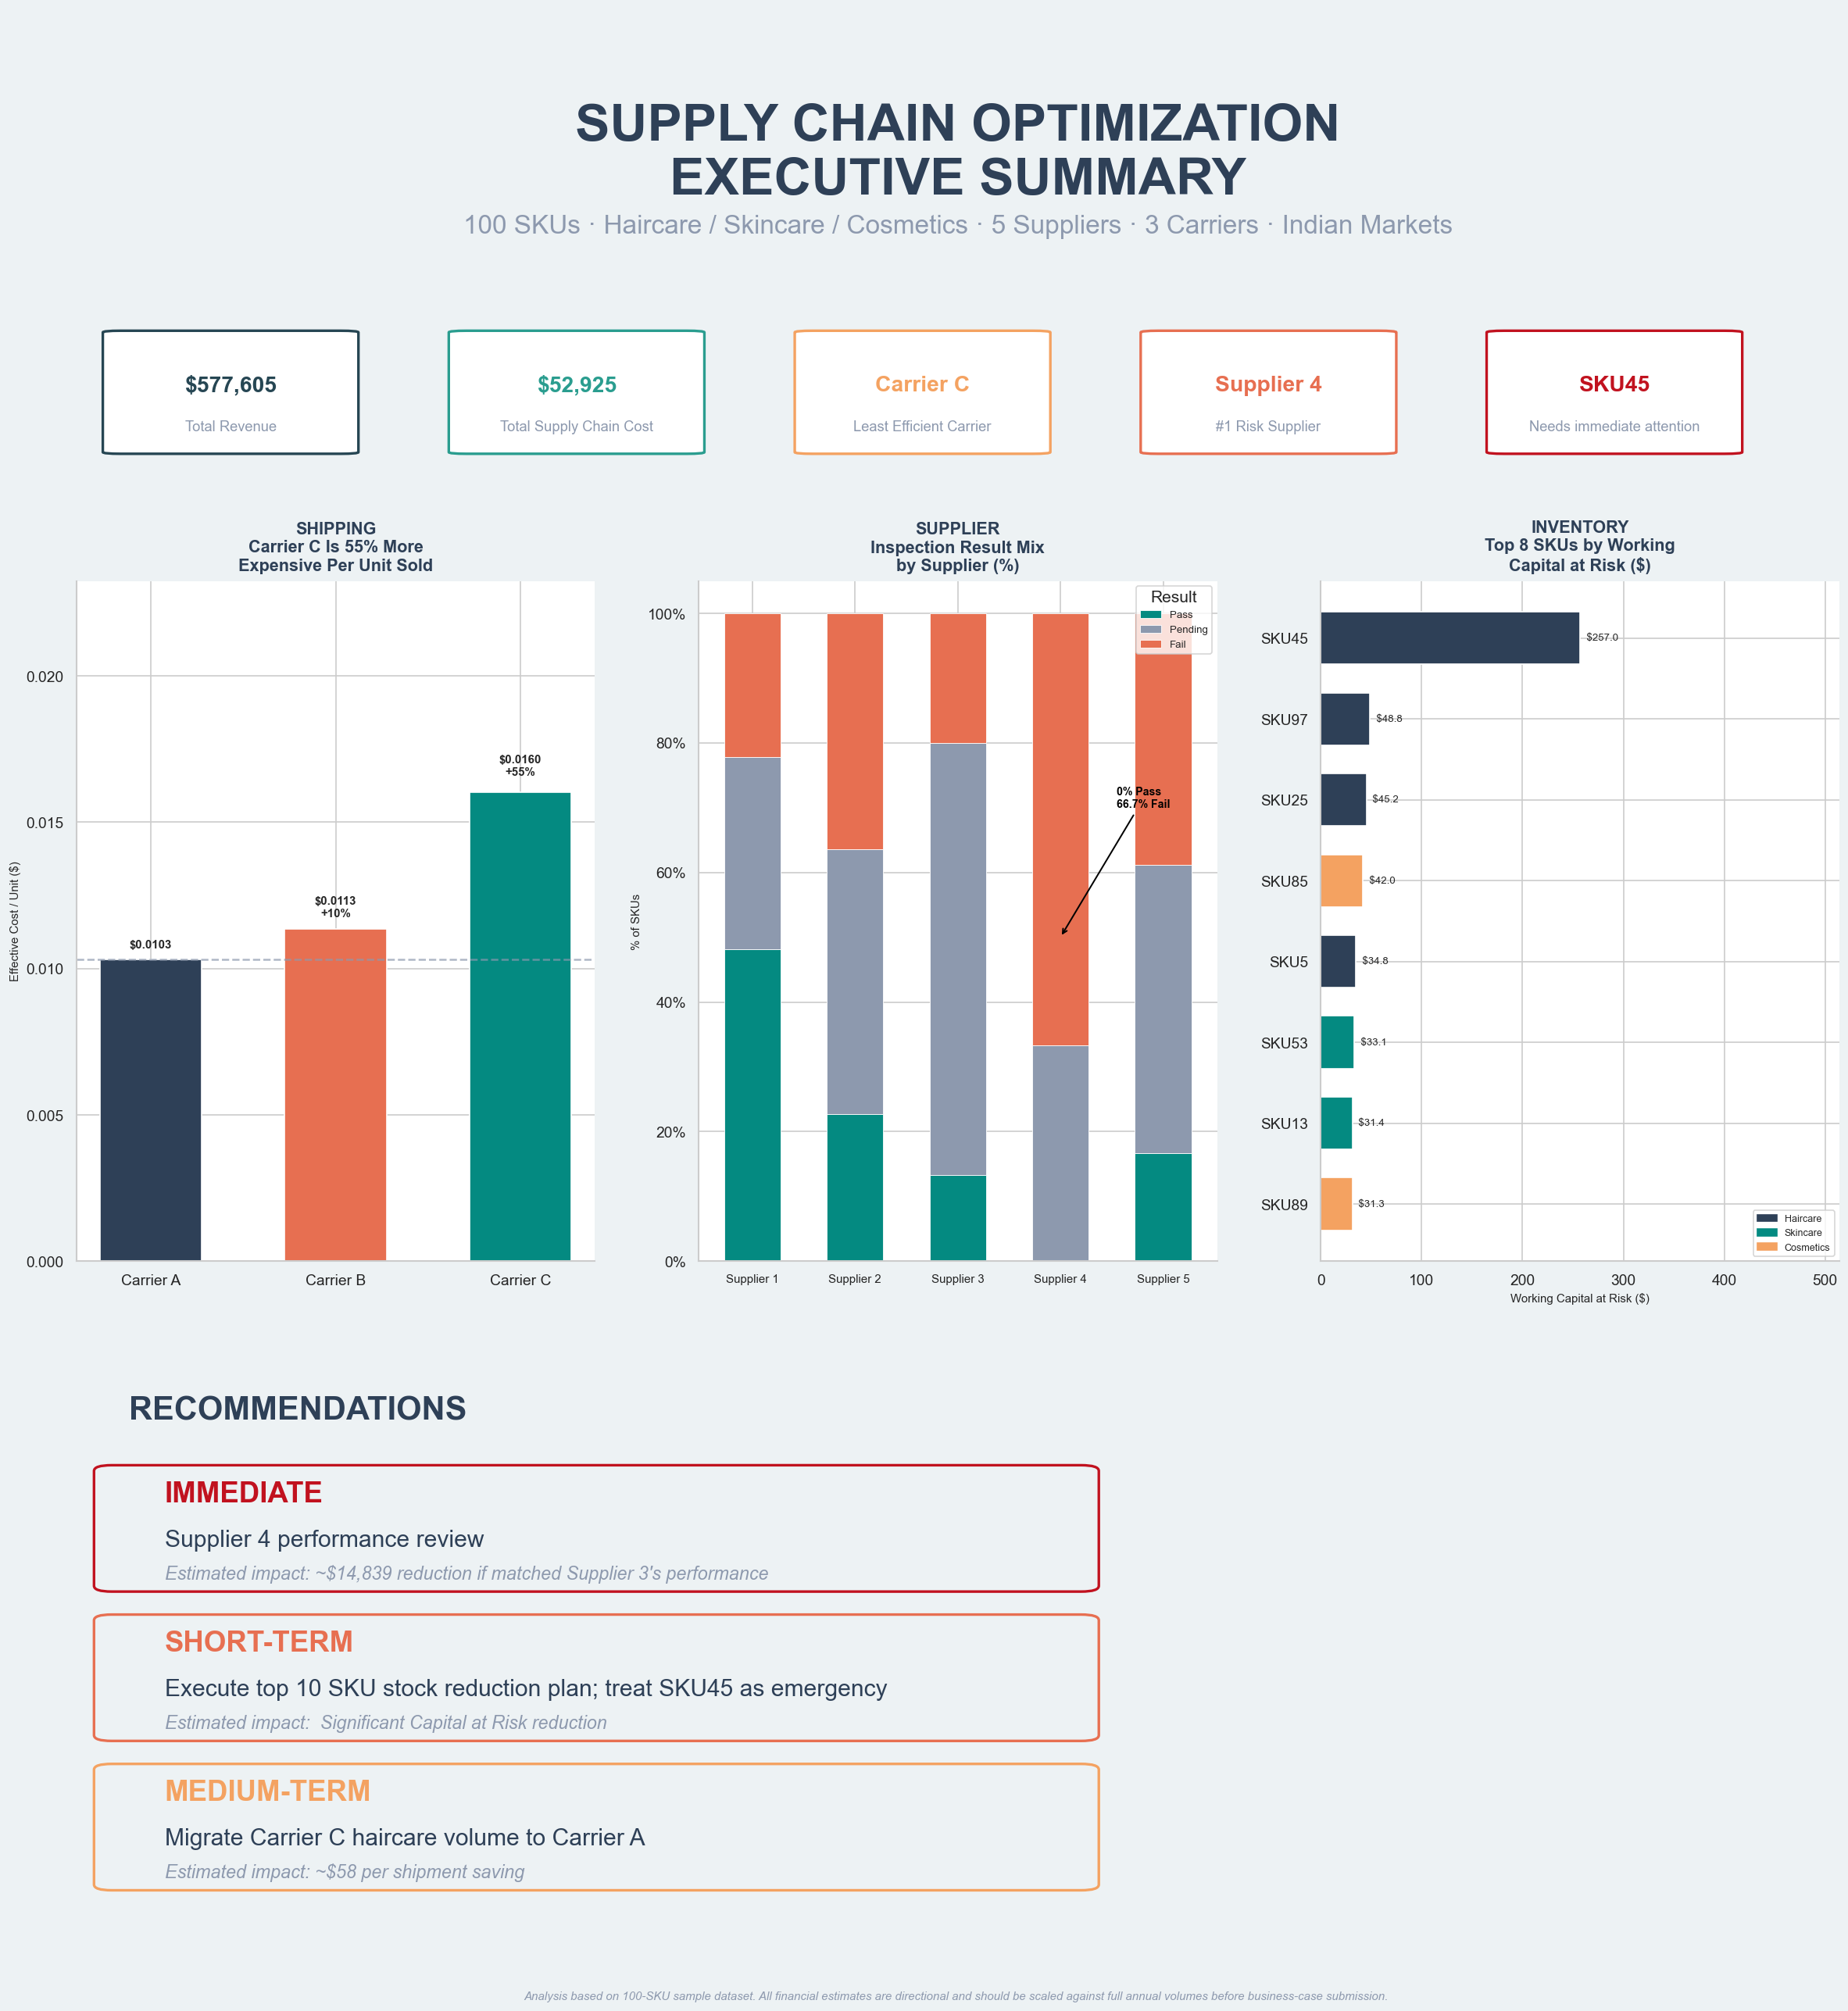

In [6]:
fig = plt.figure(figsize=(20, 22), facecolor=COLORS['light'])
gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    height_ratios=[1.2, 1.1, 4.5, 3.8],
    hspace=0.28, wspace=0.20,
    left=0.03, right=0.97, top=0.97, bottom=0.03
)


ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(COLORS['primary'])
ax_title.text(0.5, 0.2, 'SUPPLY CHAIN OPTIMIZATION\nEXECUTIVE SUMMARY',
              transform=ax_title.transAxes, ha='center', va='center',
              fontsize=40, fontweight='bold', color=COLORS['primary'])
ax_title.text(0.5, -0.2,
              '100 SKUs · Haircare / Skincare / Cosmetics · 5 Suppliers · 3 Carriers · Indian Markets',
              transform=ax_title.transAxes, ha='center', va='center',
              fontsize=20, color='#8D99AE')
ax_title.axis('off')


ax_kpi = fig.add_subplot(gs[1, :])
ax_kpi.set_facecolor(COLORS['light'])
ax_kpi.axis('off')

kpis = [
    ('$577,605', 'Total Revenue', '#264653'),
    ('$52,925', 'Total Supply Chain Cost', '#2A9D8F'),
    ('Carrier C', 'Least Efficient Carrier', '#F4A261'),
    ('Supplier 4', '#1 Risk Supplier', '#E76F51'),
    ('SKU45', 'Needs immediate attention', '#C1121F'),
]
tile_w, tile_h = 0.125, 0.72
start_x = 0.025
gap = (1.0 - start_x*2 - tile_w*len(kpis)) / (len(kpis) - 1) - 0.01

for i, (val, label, color) in enumerate(kpis):
    x = start_x + i * (tile_w + gap)
    rect = FancyBboxPatch((x, 0.10), tile_w, tile_h,
                           boxstyle='round,pad=0.01',
                           facecolor='white', edgecolor=color, linewidth=2,
                           transform=ax_kpi.transAxes, clip_on=False)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x + tile_w/2, 0.5, val,
                transform=ax_kpi.transAxes, ha='center', va='center',
                fontsize=17, fontweight='bold', color=color)
    ax_kpi.text(x + tile_w/2, 0.25, label,
                transform=ax_kpi.transAxes, ha='center', va='center',
                fontsize=11, color=COLORS['neutral'])


ax_q1 = fig.add_subplot(gs[2, 0])
ax_q1.set_facecolor('white')
carrier_agg_es = df.groupby('shipping_carriers', observed=True).agg(
    ts=('shipping_costs','sum'), tu=('number_of_products_sold','sum')
).reset_index()
carrier_agg_es['cpu'] = carrier_agg_es['ts'] / carrier_agg_es['tu']
bench = carrier_agg_es['cpu'].min()
carrier_agg_es['prem'] = ((carrier_agg_es['cpu']/bench)-1)*100
carriers_es = carrier_agg_es['shipping_carriers'].tolist()
bars_q1 = ax_q1.bar(carriers_es, carrier_agg_es['cpu'],
                    color=[CARRIER_COLORS[c] for c in carriers_es],
                    edgecolor='white', width=0.55)
ax_q1.axhline(bench, color=COLORS['neutral'], linestyle='--', lw=1.5, alpha=0.7)
for bar, row in zip(bars_q1, carrier_agg_es.itertuples()):
    lbl = f'${row.cpu:.4f}'
    if row.prem > 1:
        lbl += f'\n+{row.prem:.0f}%'
    ax_q1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
               lbl, ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_q1.set_title('SHIPPING\nCarrier C Is 55% More\nExpensive Per Unit Sold',
                color=COLORS['primary'], pad=8)
ax_q1.set_ylabel('Effective Cost / Unit ($)', fontsize=9)
ax_q1.set_ylim(0, carrier_agg_es['cpu'].max() * 1.45)
sns.despine(ax=ax_q1)


ax_q2 = fig.add_subplot(gs[2, 1])
ax_q2.set_facecolor('white')

SUPPLIER_ORDER_ES = ['Supplier 1', 'Supplier 2', 'Supplier 3', 'Supplier 4', 'Supplier 5']

insp_pivot_es = (df.groupby(['supplier_name', 'inspection_results'], observed=True)
                   .size().unstack(fill_value=0)
                   .reindex(columns=['Pass', 'Pending', 'Fail']))
insp_pct_es = insp_pivot_es.div(insp_pivot_es.sum(axis=1), axis=0) * 100
insp_pct_es = insp_pct_es.loc[SUPPLIER_ORDER_ES]

insp_pct_es.plot(kind='bar', stacked=True, ax=ax_q2,
                 color=[COLORS['secondary'], COLORS['neutral'], COLORS['accent']],
                 edgecolor='white', linewidth=0.5, width=0.55)

s4_idx_es = SUPPLIER_ORDER_ES.index('Supplier 4')
ax_q2.annotate('0% Pass\n66.7% Fail',
               xy=(s4_idx_es, 50), xytext=(s4_idx_es + 0.55, 70),
               fontsize=8.5, fontweight='bold', color='black',
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax_q2.set_title('SUPPLIER\nInspection Result Mix\nby Supplier (%)',
                color=COLORS['primary'], pad=8)
ax_q2.set_xlabel('')
ax_q2.set_xticklabels(SUPPLIER_ORDER_ES, rotation=0, ha='center', fontsize=9)
ax_q2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_q2.set_ylabel('% of SKUs', fontsize=9)
ax_q2.legend(title='Result', fontsize=8, loc='upper right')
sns.despine(ax=ax_q2)


ax_q3 = fig.add_subplot(gs[2, 2])
ax_q3.set_facecolor('white')

top8_wcar = (df.nlargest(8, 'working_capital_at_risk')
               .sort_values('working_capital_at_risk', ascending=True))
bar_cols_q3 = [PRODUCT_COLORS[p] for p in top8_wcar['product_type']]
ax_q3.barh(top8_wcar['sku'], top8_wcar['working_capital_at_risk'],
           color=bar_cols_q3, edgecolor='white', height=0.65)

for i, (_, row) in enumerate(top8_wcar.iterrows()):
    ax_q3.text(row['working_capital_at_risk'] + 0.5, i,
               f"  ${row['working_capital_at_risk']:.1f}", va='center', fontsize=8)

leg_h = [mpatches.Patch(color=PRODUCT_COLORS[p], label=p.capitalize())
         for p in ['haircare', 'skincare', 'cosmetics']]
ax_q3.legend(handles=leg_h, fontsize=7.5, loc='lower right')
ax_q3.set_title('INVENTORY\nTop 8 SKUs by Working\nCapital at Risk ($)',
                color=COLORS['primary'], pad=8)
ax_q3.set_xlabel('Working Capital at Risk ($)', fontsize=9)
ax_q3.set_xlim(0, top8_wcar['working_capital_at_risk'].max() * 2.0)
sns.despine(ax=ax_q3)


ax_rec = fig.add_subplot(gs[3, :])
ax_rec.set_facecolor('white')
ax_rec.axis('off')

ax_rec.text(0.03, 0.96, 'RECOMMENDATIONS',
            transform=ax_rec.transAxes, fontsize=25,
            fontweight='bold', color=COLORS['primary'], va='top')

recs = [
    ('IMMEDIATE',
     'Supplier 4 performance review',
     "~$14,839 reduction if matched Supplier 3's performance", '#C1121F'),
    ('SHORT-TERM',
     'Execute top 10 SKU stock reduction plan; treat SKU45 as emergency',
     ' Significant Capital at Risk reduction', '#E76F51'),
    ('MEDIUM-TERM',
     'Migrate Carrier C haircare volume to Carrier A',
     '~$58 per shipment saving', '#F4A261'),
]

row_y = [0.70, 0.44, 0.18]
for (header, body, impact, color), y in zip(recs, row_y):
    rect = FancyBboxPatch((0.02, y - 0.07), 0.55, 0.20,
                           boxstyle='round,pad=0.01',
                           facecolor='#EDF2F4', edgecolor=color, linewidth=2,
                           transform=ax_rec.transAxes, clip_on=False)
    ax_rec.add_patch(rect)
    ax_rec.text(0.05, y + 0.09, header,
                transform=ax_rec.transAxes, fontsize=22,
                fontweight='bold', color=color, va='center')
    ax_rec.text(0.05, y + 0.01, body,
                transform=ax_rec.transAxes, fontsize=18,
                color=COLORS['primary'], va='center')
    ax_rec.text(0.05, y - 0.049, f'Estimated impact: {impact}',
                transform=ax_rec.transAxes, fontsize=14,
                color=COLORS['neutral'], va='center', style='italic')


fig.text(0.5, 0.005,
         'Analysis based on 100-SKU sample dataset. All financial estimates are directional '
         'and should be scaled against full annual volumes before business-case submission. ',
         ha='center', fontsize=9, color=COLORS['neutral'], style='italic')

plt.show()